<a href="https://colab.research.google.com/github/lkssraw-7/shot-logs-nba/blob/main/Copy_of_Atividade_1_BigData_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Configuração Inicial e Carregamento de Dados

Esta seção inclui a importação das bibliotecas necessárias e o carregamento inicial do dataset, além de uma breve exploração para entender sua estrutura.

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
df = pd.read_csv('shot_logs.csv')
df=df.dropna()
print("Primeiras linhas da base:")
print(df.head())

print("\nDimensão da base:")
print(df.shape)

print("\nInformações da base:")
print(df.info())



Primeiras linhas da base:
    GAME_ID                   MATCHUP LOCATION  W  FINAL_MARGIN  SHOT_NUMBER  \
0  21400899  MAR 04, 2015 - CHA @ BKN        A  W            24            1   
1  21400899  MAR 04, 2015 - CHA @ BKN        A  W            24            2   
3  21400899  MAR 04, 2015 - CHA @ BKN        A  W            24            4   
4  21400899  MAR 04, 2015 - CHA @ BKN        A  W            24            5   
5  21400899  MAR 04, 2015 - CHA @ BKN        A  W            24            6   

   PERIOD GAME_CLOCK  SHOT_CLOCK  DRIBBLES  ...  SHOT_DIST  PTS_TYPE  \
0       1       1:09        10.8         2  ...        7.7         2   
1       1       0:14         3.4         0  ...       28.2         3   
3       2      11:47        10.3         2  ...       17.2         2   
4       2      10:34        10.9         2  ...        3.7         2   
5       2       8:15         9.1         2  ...       18.4         2   

   SHOT_RESULT   CLOSEST_DEFENDER CLOSEST_DEFENDER_PLAYER_ID

## 2. Preparação e Seleção de Atributos

Nesta parte, os dados são preparados, incluindo a seleção das colunas relevantes para as análises subsequentes.

In [27]:
df = df[['player_name','SHOT_DIST','PTS_TYPE', 'SHOT_RESULT','CLOSEST_DEFENDER','CLOSE_DEF_DIST', 'FGM']]
df

,player_name,SHOT_DIST,PTS_TYPE,SHOT_RESULT,CLOSEST_DEFENDER,CLOSE_DEF_DIST,FGM
0,brian roberts,7.7,2,made,"Anderson, Alan",1.3,1
1,brian roberts,28.2,3,missed,"Bogdanovic, Bojan",6.1,0
3,brian roberts,17.2,2,missed,"Brown, Markel",3.4,0
4,brian roberts,3.7,2,missed,"Young, Thaddeus",1.1,0
5,brian roberts,18.4,2,missed,"Williams, Deron",2.6,0
...,...,...,...,...,...,...,...
128063,jarrett jack,8.9,2,made,"Sullinger, Jared",5.7,1
128064,jarrett jack,8.7,2,missed,"Smart, Marcus",0.8,0
128065,jarrett jack,0.6,2,made,"Turner, Evan",0.6,1
128066,jarrett jack,16.9,2,made,"Thornton, Marcus",4.2,1


## 3. Análise de Métricas Chave e Estatísticas de Jogadores

Esta seção foca na extração de métricas importantes, como a taxa geral de acerto, eficiência por tipo e distância de arremesso, e estatísticas sobre jogadores e defensores.

In [28]:
df['SHOT_DIST_M'] = df['SHOT_DIST'] * 0.3048
df['CLOSE_DEF_DIST_M'] = df['CLOSE_DEF_DIST'] * 0.3048

In [29]:
print("\nTaxa geral de acerto:")
print(df['FGM'].mean())



print("\nEficiência por tipo de arremesso:")
print(df.groupby('PTS_TYPE')['FGM'].mean())


print("\nEficiência por distância do arremesso:")
print(df.groupby(pd.cut(df['SHOT_DIST_M'], bins=7))['FGM'].mean())


print("\nEficiência por distância do defensor:")
print(df.groupby(pd.cut(df['CLOSE_DEF_DIST_M'], bins=5))['FGM'].mean())


print("\nTop 10 jogadores com mais arremessos:")
print(df['player_name'].value_counts().head(10))


tentativas = df['player_name'].value_counts()
players_validos1 = tentativas[tentativas > 50].index

print("\nJogadores mais eficientes (mínimo 50 arremessos):")
print(df[df['player_name'].isin(players_validos1)]
      .groupby('player_name')['FGM']
      .mean()
      .sort_values(ascending=False)
      .head(10))


print("\nDefensores que mais aparecem nos arremessos:")
print(df['CLOSEST_DEFENDER'].value_counts().head(10))






Taxa geral de acerto:
0.4561558178641981

Eficiência por tipo de arremesso:
PTS_TYPE
2    0.489455
3    0.360569
Name: FGM, dtype: float64

Eficiência por distância do arremesso:
SHOT_DIST_M
(-0.0133, 1.894]    0.592375
(1.894, 3.788]      0.410756
(3.788, 5.682]      0.421786
(5.682, 7.576]      0.380386
(7.576, 9.471]      0.332213
(9.471, 11.365]     0.154762
(11.365, 13.259]    0.117647
Name: FGM, dtype: float64

Eficiência por distância do defensor:
CLOSE_DEF_DIST_M
(-0.0162, 3.243]    0.455096
(3.243, 6.486]      0.482581
(6.486, 9.729]      0.705128
(9.729, 12.972]     1.000000
(12.972, 16.215]    1.000000
Name: FGM, dtype: float64

Top 10 jogadores com mais arremessos:
player_name
lamarcus aldridge    1010
james harden         1006
mnta ellis           1004
klay thompson         953
lebron james          947
russell westbrook     943
stephen curry         941
damian lillard        925
kyrie irving          919
nikola vucevic        889
Name: count, dtype: int64

Jogadores mais

/tmp/ipykernel_1138/1152326580.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby(pd.cut(df['SHOT_DIST_M'], bins=7))['FGM'].mean())
/tmp/ipykernel_1138/1152326580.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby(pd.cut(df['CLOSE_DEF_DIST_M'], bins=5))['FGM'].mean())


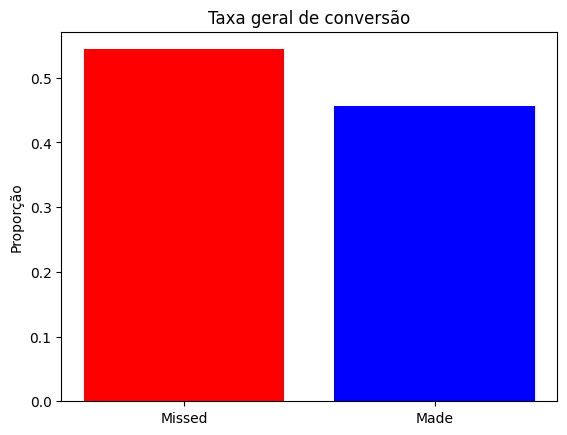

In [30]:
fgm_counts = df['FGM'].value_counts(normalize=True)

plt.figure()
plt.bar(['Missed','Made'], [fgm_counts.get(0,0), fgm_counts.get(1,0)], color = ['red','blue'])
plt.title("Taxa geral de conversão")
plt.ylabel("Proporção")
plt.show()


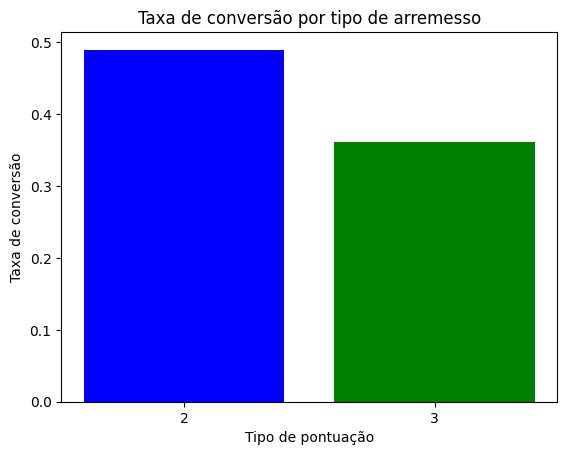

In [31]:
pts_eff = df.groupby('PTS_TYPE')['FGM'].mean()

plt.figure()
plt.bar(pts_eff.index.astype(str), pts_eff.values, color=['blue','green'])
plt.title("Taxa de conversão por tipo de arremesso")
plt.xlabel("Tipo de pontuação")
plt.ylabel("Taxa de conversão")
plt.show()

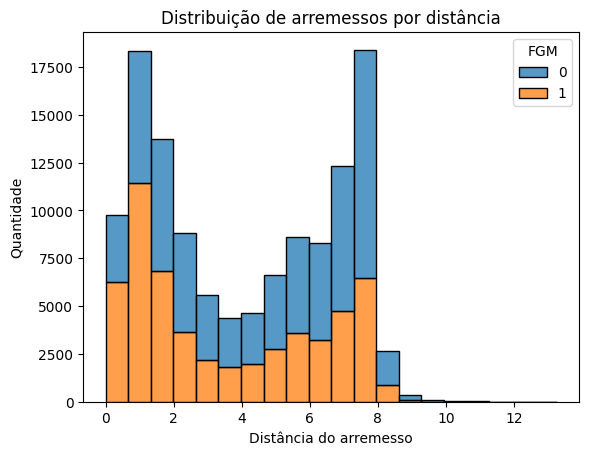

In [42]:

plt.figure()

sns.histplot(data=df, x="SHOT_DIST_M", hue="FGM", bins=20, multiple="stack")

plt.title("Distribuição de arremessos por distância")
plt.xlabel("Distância do arremesso")
plt.ylabel("Quantidade")

plt.show()

/tmp/ipykernel_1138/18927093.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dist_eff = df.groupby(dist_bins)['FGM'].mean()


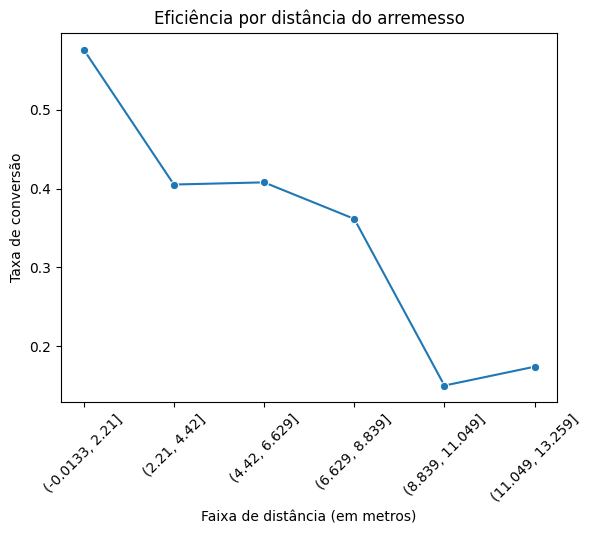

In [41]:
dist_bins = pd.cut(df['SHOT_DIST_M'], bins=6)
dist_eff = df.groupby(dist_bins)['FGM'].mean()

plt.figure()

sns.lineplot(
    x=dist_eff.index.astype(str),
    y=dist_eff.values,
    marker="o"
)

plt.xticks(rotation=45)

plt.title("Eficiência por distância do arremesso")
plt.xlabel("Faixa de distância (em metros)")
plt.ylabel("Taxa de conversão")

plt.show()

/tmp/ipykernel_1138/531027436.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  def_eff = df.groupby(def_bins)['FGM'].mean()


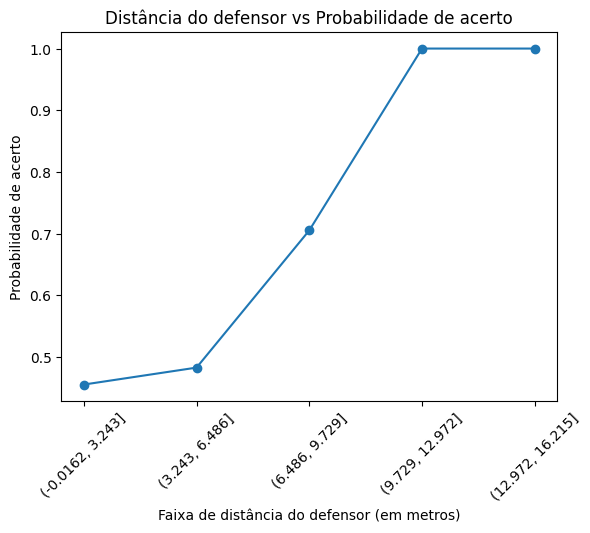

In [39]:
# Distância do defensor
def_bins = pd.cut(df['CLOSE_DEF_DIST_M'], bins=5)
def_eff = df.groupby(def_bins)['FGM'].mean()

plt.figure()
plt.plot(def_eff.index.astype(str), def_eff.values, marker='o')
plt.xticks(rotation=45)
plt.title("Distância do defensor vs Probabilidade de acerto")
plt.xlabel("Faixa de distância do defensor (em metros)")
plt.ylabel("Probabilidade de acerto")
plt.show()


## 4. Visualizações

Esta parte é dedicada à criação de gráficos e visualizações para ilustrar as métricas e tendências identificadas nas análises.

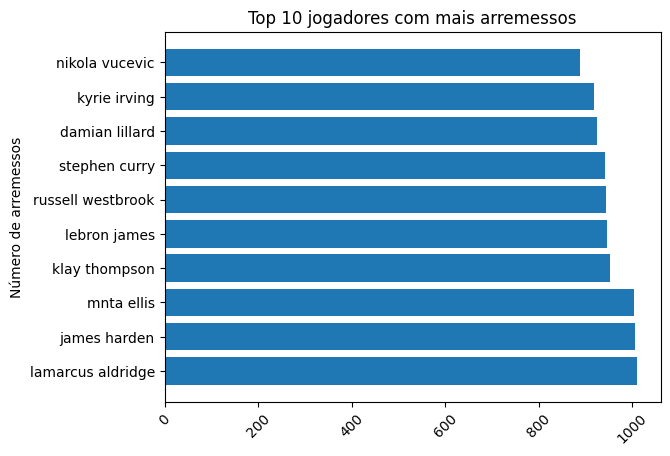

In [35]:
# Top jogadores com mais arremessos
mais_arremesos = df['player_name'].value_counts().head(10)

plt.figure()
plt.barh(mais_arremesos.index, mais_arremesos.values)
plt.xticks(rotation=45)
plt.title("Top 10 jogadores com mais arremessos")
plt.ylabel("Número de arremessos")
plt.show()

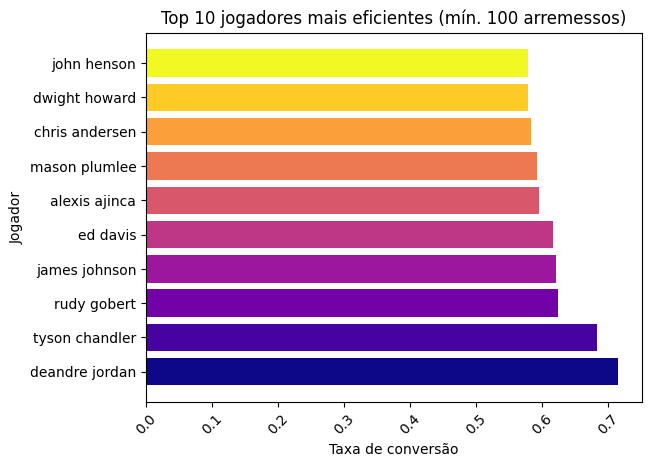

In [36]:
#Top jogadores com mais taxa de conversão


tentativas = df['player_name'].value_counts()

players_validos2 = tentativas[tentativas >= 100].index

mais_conversao = (
    df[df['player_name'].isin(players_validos2)]
    .groupby('player_name')['FGM']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)
cores = plt.cm.plasma(np.linspace(0,1,len(mais_conversao)))
plt.figure()

plt.barh(mais_conversao.index, mais_conversao.values, color=cores)

plt.xticks(rotation=45)
plt.title("Top 10 jogadores mais eficientes (mín. 100 arremessos)")
plt.ylabel("Jogador")
plt.xlabel("Taxa de conversão")

plt.show()

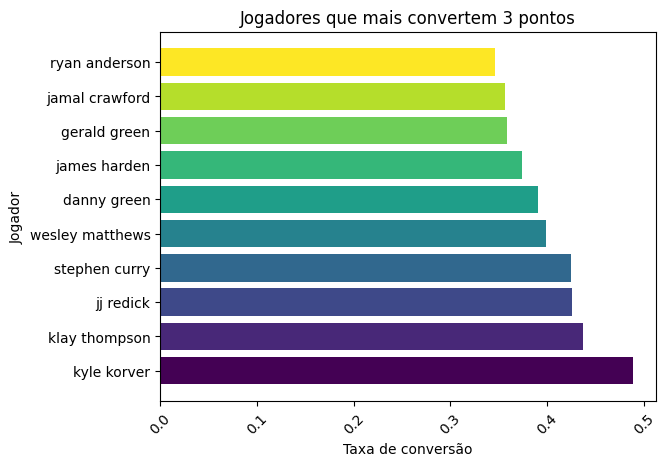

In [37]:
df_3pt = df[df['PTS_TYPE']==3]

tentativas_3pt = df_3pt['player_name'].value_counts()

players_validos3 = tentativas_3pt[tentativas_3pt >= 300].index

top_3pt = (
    df_3pt[df_3pt['player_name'].isin(players_validos3)]
    .groupby('player_name')['FGM']
    .mean()
    .sort_values(ascending=False)
    .head(10)
    )

cores = plt.cm.viridis(np.linspace(0,1,len(top_3pt)))

plt.figure()
plt.barh(top_3pt.index, top_3pt.values, color=cores)
plt.xticks(rotation=45)
plt.title('Jogadores que mais convertem 3 pontos')
plt.xlabel('Taxa de conversão')
plt.ylabel('Jogador')
plt.show()